# Training Reasoning Models with Reinforcement Learning

#### Loading model and tokenizer

In [1]:
import pathlib
import torch
import sympy
import tokenizers

In [2]:
device = torch.device("gpu" if torch.cuda.is_available() else "cpu")

In [3]:
from utils import load_model_tokenizer
model, tokenizer = load_model_tokenizer("base", device)

## RLVR using GRPO

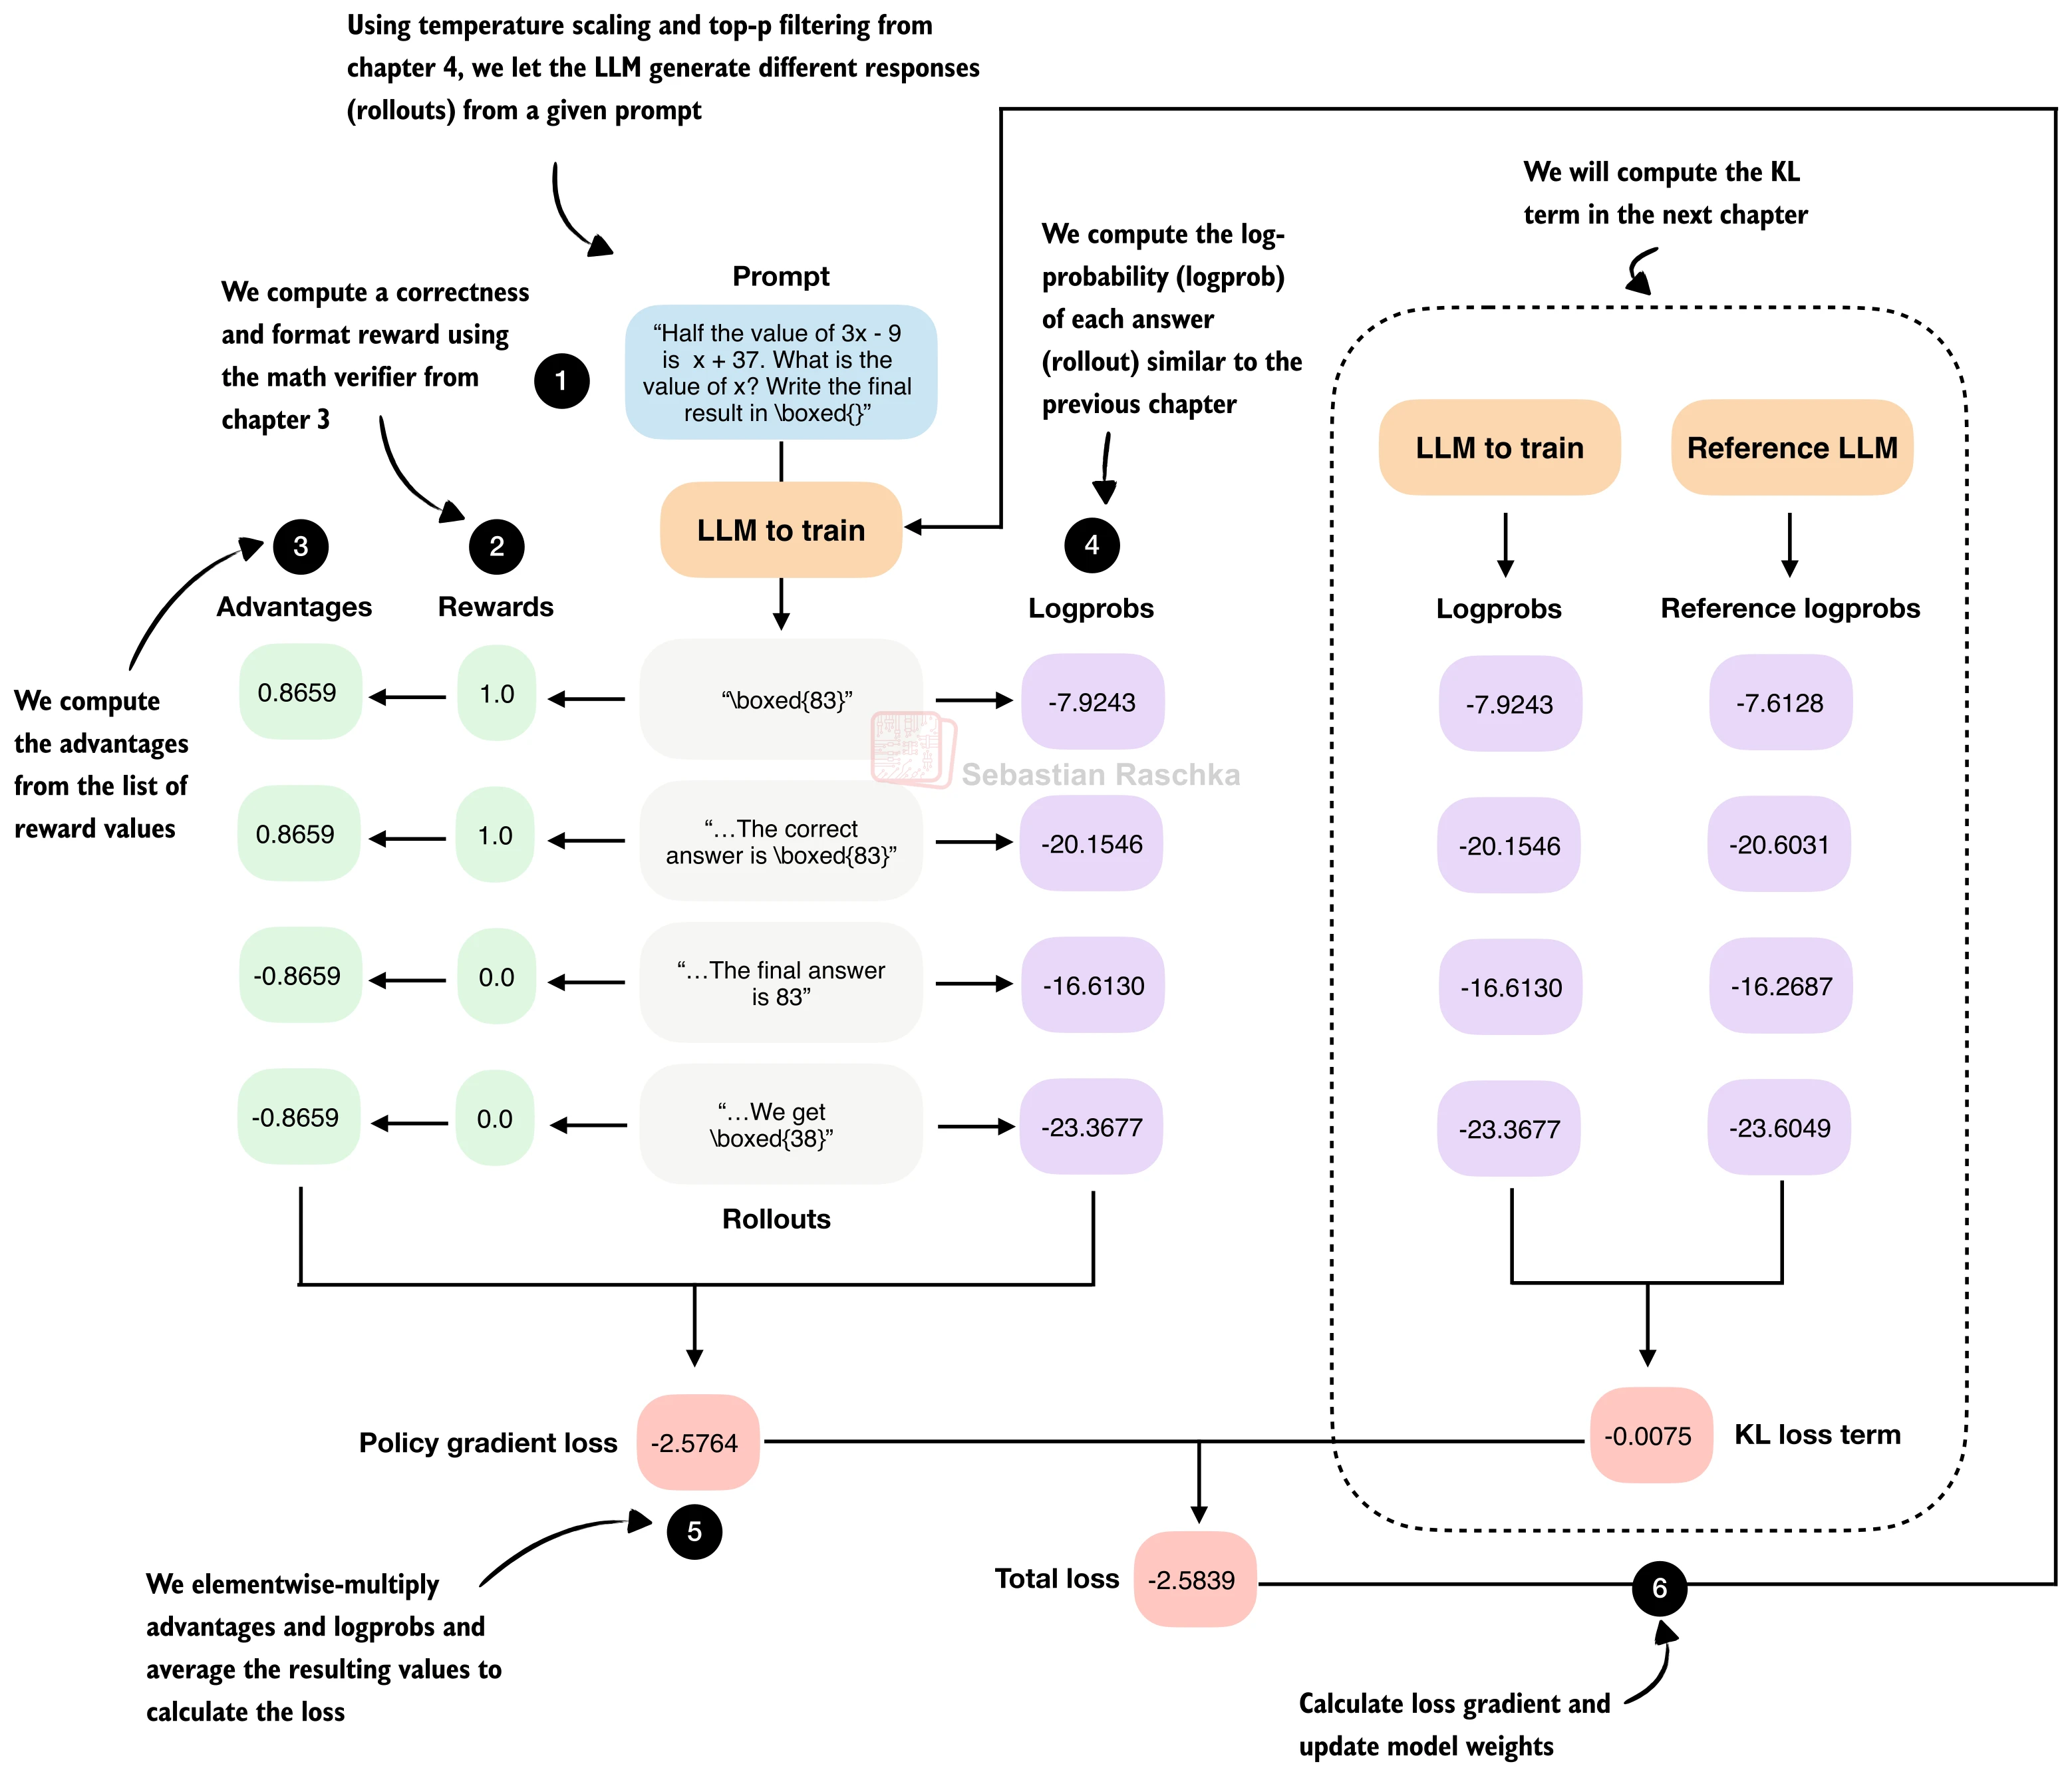

In [4]:
import json
import requests
from pathlib import Path

def load_math_train(local_path="math_train.json", save_copy=True):
    local_path = Path(local_path)

    url = (
        "https://raw.githubusercontent.com/rasbt/"
        "math_full_minus_math500/refs/heads/main/"
        "math_full_minus_math500.json"
    )
    backup_url = (
        "https://f001.backblazeb2.com/file/reasoning-from-scratch/"
        "MATH/math_full_minus_math500.json"
    )

    if local_path.exists():
        with local_path.open("r", encoding="utf-8") as f:
            data = json.load(f)
    else:
        try:
            r = requests.get(url, timeout=30)
            r.raise_for_status()
        except requests.RequestException:
            print("Using backup URL.")
            r = requests.get(backup_url, timeout=30)
            r.raise_for_status()

        data = r.json()

        if save_copy:
            with local_path.open("w", encoding="utf-8") as f:
                json.dump(data, f, indent=2)

    return data

In [5]:
math_train = load_math_train()

print("Dataset size:", len(math_train))

Dataset size: 12000


In [6]:
from pprint import pprint
pprint(math_train[67])

{'answer': '-112',
 'level': 'Level 4',
 'problem': 'Let $p$ and $q$ be the two distinct solutions to the equation '
            '$$(x-5)(2x+9) = x^2-13x+40.$$What is $(p + 3)(q + 3)$?',
 'solution': 'We can expand the left side to simplify, or we might notice that '
             '$x^2-13x+40 = (x-5)(x-8).$ Thus, we see that $(x-5)(2x+9) = '
             '(x-5)(x-8).$ Simplifying, we have $(x-5)(2x+9) - (x-5)(x-8) = '
             '(x-5)(x+17) = 0.$ Therefore, $p$ and $q$ are 5 and -17, and $(p '
             '+ 3)(q + 3) = (8) (-14) = \\boxed{-112}.$',
 'type': 'Algebra',
 'unique_id': 67}


In [7]:
from reasoning_from_scratch.qwen3 import KVCache
from reasoning_from_scratch.ch04 import top_p_filter

@torch.no_grad()
def sample_response(model, tokenizer, prompt, device, max_new_tokens=512, temperature = 0.8, top_p = 0.9):
    input_ids = torch.tensor(tokenizer.encode(prompt), device=device)
    cache = KVCache(n_layers=model.cfg["n_layers"])
    model.reset_kv_cache()
    logits = model(input_ids.unsqueeze(0), cache = cache)[:, -1]

    generated = []
    for i in range(max_new_tokens):
        if temperature != 0.0 or temperature is not None:
            logits = logits/temperature
        
        prob = torch.softmax(logits, dim = -1)
        prob = top_p_filter(prob, top_p)

        next_token = torch.multinomial(prob.cpu(), 1).to(device)
        token_id = next_token.item()
        generated.append(token_id)

        if(tokenizer.eos_token_id is not None and tokenizer.eos_token_id == token_id):
            break

        logits = model(next_token, cache = cache)[:, -1]

    full_token_ids = torch.cat([input_ids,torch.tensor(generated, device=device, dtype=input_ids.dtype)])
    return full_token_ids, input_ids.numel(), tokenizer.decode(generated)

#### Rollouts

In actual RLVR we would generate multiple rollouts, but for the sake of simplicity assume the following:

In [8]:
rollouts = [
    r"\boxed{83}",
    r"The correct answer is \boxed{83}",
    r"The final answer is 83",
    r"We get \boxed{38}",
]

#### Rewards

In [9]:
from reasoning_from_scratch.ch03 import (extract_final_candidate, grade_answer)
def reward_rlvr(answer_text, ground_truth):
    answer = extract_final_candidate(answer_text, fallback=None)
    if not answer:
        return 0.0
    correct = grade_answer(answer, ground_truth)
    return float(correct)        

In [10]:
rollout_list = []
for r in rollouts:
    reward = reward_rlvr(r, "83")
    print(f"Answer: {r!r}")
    print(f"Reward: {reward}\n")
    rollout_list.append(reward)

Answer: '\\boxed{83}'
Reward: 1.0

Answer: 'The correct answer is \\boxed{83}'
Reward: 1.0

Answer: 'The final answer is 83'
Reward: 0.0

Answer: 'We get \\boxed{38}'
Reward: 0.0



#### Advantage formula
- Here, ri denotes the reward of the i-th rollout, 
- mu-r is the mean reward across the group of rollouts, 
- sigma-r is the corresponding standard deviation, and 
- epsilon is a small constant added for numerical stability to avoid zero-division errors

<math xmlns="http://www.w3.org/1998/Math/MathML" display="block">
  <msub>
    <mtext>advantages</mtext>
    <mi>i</mi>
  </msub>
  <mo>=</mo>
  <mfrac>
    <mrow>
      <msub>
        <mi>r</mi>
        <mi>i</mi>
      </msub>
      <mo>&#x2212;</mo>
      <msub>
        <mi>&#x3BC;</mi>
        <mi>r</mi>
      </msub>
    </mrow>
    <mrow>
      <msub>
        <mi>&#x3C3;</mi>
        <mi>r</mi>
      </msub>
      <mo>+</mo>
      <mi>&#x3F5;</mi>
    </mrow>
  </mfrac>
</math>

In [11]:
rewards = torch.tensor(rollout_list, device = device)
rewards

tensor([1., 1., 0., 0.])

In [12]:
advantages = (rewards - rewards.mean())/(rewards.std() + 1e-6)
advantages

tensor([ 0.8660,  0.8660, -0.8660, -0.8660])

#### Scoring rollouts with sequence log-probabilities

In [23]:
def sequence_logprob(model, token_ids, prompt_len):
    logits = model(token_ids.unsqueeze(0)).squeeze(0).float()
    logprobs = torch.log_softmax(logits, dim=-1)
    selected = logprobs[:-1].gather(1, token_ids[1:].unsqueeze(-1)).squeeze(-1)
    return torch.sum(selected[prompt_len - 1:]) #sum not mean since this naturally penalizes longer answers

In [19]:
from utils import render_prompt

raw_prompt = (
    "Half the value of $3x-9$ is $x+37$. "
    "What is the value of $x$?"
)
prompt = render_prompt(raw_prompt)

token_ids, prompt_len, answer_text = sample_response(
            model=model,
            tokenizer=tokenizer,
            prompt=prompt,
            device=device,
            max_new_tokens=512,
            temperature=0.9,
            top_p=0.9,
        )

In [20]:
rollout_logps = []

for text in rollouts:
    token_ids = tokenizer.encode(prompt + " " + text)
    logprob = sequence_logprob(
        model=model,
        token_ids=torch.tensor(token_ids, device=device),
        prompt_len=prompt_len,
    )

    print(f"Answer:  {text}")
    print(f"Logprob: {logprob.item():.4f}\n")

    rollout_logps.append(logprob)

Answer:  \boxed{83}
Logprob: -8.1990

Answer:  The correct answer is \boxed{83}
Logprob: -19.9214

Answer:  The final answer is 83
Logprob: -16.3653

Answer:  We get \boxed{38}
Logprob: -23.1454



In [21]:
logps = torch.stack(rollout_logps)
print(logps)

tensor([ -8.1990, -19.9214, -16.3653, -23.1454], grad_fn=<StackBackward0>)


#### Policy Gradient Loss

<math xmlns="http://www.w3.org/1998/Math/MathML" display="block">
  <msub>
    <mrow data-mjx-texclass="ORD">
      <mi data-mjx-variant="-tex-calligraphic" mathvariant="script">L</mi>
    </mrow>
    <mrow data-mjx-texclass="ORD">
      <mrow data-mjx-texclass="ORD">
        <mi data-mjx-auto-op="false">PG</mi>
      </mrow>
    </mrow>
  </msub>
  <mo>=</mo>
  <mo>&#x2212;</mo>
  <mfrac>
    <mn>1</mn>
    <mi>N</mi>
  </mfrac>
  <munderover>
    <mo data-mjx-texclass="OP">&#x2211;</mo>
    <mrow data-mjx-texclass="ORD">
      <mi>i</mi>
      <mo>=</mo>
      <mn>1</mn>
    </mrow>
    <mrow data-mjx-texclass="ORD">
      <mi>N</mi>
    </mrow>
  </munderover>
  <msub>
    <mi>A</mi>
    <mi>i</mi>
  </msub>
  <munderover>
    <mo data-mjx-texclass="OP">&#x2211;</mo>
    <mrow data-mjx-texclass="ORD">
      <mi>t</mi>
      <mo>=</mo>
      <mn>1</mn>
    </mrow>
    <mrow data-mjx-texclass="ORD">
      <msub>
        <mi>T</mi>
        <mi>i</mi>
      </msub>
    </mrow>
  </munderover>
  <mi>log</mi>
  <mo data-mjx-texclass="NONE">&#x2061;</mo>
  <msub>
    <mi>p</mi>
    <mi>W</mi>
  </msub>
  <mstyle>
    <mspace width="-0.167em"></mspace>
  </mstyle>
  <mrow data-mjx-texclass="INNER">
    <mo data-mjx-texclass="OPEN">(</mo>
    <msubsup>
      <mi>y</mi>
      <mi>t</mi>
      <mrow data-mjx-texclass="ORD">
        <mo stretchy="false">(</mo>
        <mi>i</mi>
        <mo stretchy="false">)</mo>
      </mrow>
    </msubsup>
    <mo>&#x2223;</mo>
    <msubsup>
      <mi>y</mi>
      <mrow data-mjx-texclass="ORD">
        <mo>&lt;</mo>
        <mi>t</mi>
      </mrow>
      <mrow data-mjx-texclass="ORD">
        <mo stretchy="false">(</mo>
        <mi>i</mi>
        <mo stretchy="false">)</mo>
      </mrow>
    </msubsup>
    <mo>,</mo>
    <msup>
      <mi>x</mi>
      <mrow data-mjx-texclass="ORD">
        <mo stretchy="false">(</mo>
        <mi>i</mi>
        <mo stretchy="false">)</mo>
      </mrow>
    </msup>
    <mo data-mjx-texclass="CLOSE">)</mo>
  </mrow>
</math>

In [22]:
pg_loss = -(advantages.detach() * logps).mean()
pg_loss

#detach necessary as we want to compute gradients only for logps not for the advantages

tensor(-2.4661, grad_fn=<NegBackward0>)

#### Combined GRPO

In [42]:
math_train[2]

{'problem': 'What is the degree of the polynomial $(4 +5x^3 +100 +2\\pi x^4 + \\sqrt{10}x^4 +9)$?',
 'level': 'Level 3',
 'type': 'Algebra',
 'solution': "This polynomial is not written in standard form.  However, we don't need to write it in standard form, nor do we need to pay attention to the coefficients.  We just look for the exponents on $x$.  We have an $x^4$ term and no other term of higher degree, so $\\boxed{4}$ is the degree of the polynomial.",
 'answer': '4',
 'unique_id': 2}

In [47]:
def compute_grpo_loss(model, tokenizer, example, device, num_rollouts, max_new_tokens = 256, temperature = 0.8, top_p = 0.9):
    prompt = render_prompt(example['problem'])
    roll_logps, roll_rewards, samples = [], [], []
    assert num_rollouts >= 2

    was_training = model.training
    model.eval()

    for _ in range(num_rollouts):
        token_id, prompt_len, response = sample_response(model, tokenizer, prompt, device, max_new_tokens, temperature, top_p)
        reward = reward_rlvr(response, example['answer'])
        roll_rewards.append(reward)
        logps = sequence_logprob(model, token_id, prompt_len)
        roll_logps.append(logps)
        samples.append({
                "text": response,
                "reward": reward,
                "gen_len": token_id.numel() - prompt_len,
            })
    
    if was_training:
        model.train()
    
    rewards = torch.tensor(roll_rewards, device=device)

    advantages = (rewards - rewards.mean()) / (rewards.std() + 1e-6) 

    logps = torch.stack(roll_logps)

    policy_gradient_loss = -(advantages.detach() * logps).mean()

    loss = policy_gradient_loss #KL divergence in next chapter

    return {
        "loss": loss.item(),
        "pg_loss": pg_loss.item(),
        "rewards": roll_rewards,
        "advantages": advantages.detach().cpu().tolist(),
        "samples": samples,
        "loss_tensor": loss,
    }

In [48]:
torch.manual_seed(1234)

stats = compute_grpo_loss(
    model=model,
    tokenizer=tokenizer,
    example=math_train[67],
    device=device,
    num_rollouts=2,
    max_new_tokens=256,
    temperature=0.8,
    top_p=0.9
)

pprint(stats)

{'advantages': [0.0, 0.0],
 'loss': -0.0,
 'loss_tensor': tensor(-0., grad_fn=<NegBackward0>),
 'pg_loss': -2.4660792350769043,
 'rewards': [0.0, 0.0],
 'samples': [{'gen_len': 9,
              'reward': 0.0,
              'text': ' \n\\boxed{106}<|endoftext|>'},
             {'gen_len': 256,
              'reward': 0.0,
              'text': ' \n'
                      "Let's solve the problem step by step.\n"
                      '\n'
                      '**Step 1: Expand the given equation**\n'
                      '\n'
                      'The equation is:\n'
                      '\\[\n'
                      '(x - 5)(2x + 9) = x^2 - 13x + 40\n'
                      '\\]\n'
                      '\n'
                      'First, expand the left-hand side:\n'
                      '\\[\n'
                      '(x - 5)(2x + 9) = x \\cdot 2x + x \\cdot 9 - 5 \\cdot '
                      '2x - 5 \\cdot 9\n'
                      '\\]\n'
                      '\\[\n'
       

In [49]:
from IPython.display import display
display(stats)

{'loss': -0.0,
 'pg_loss': -2.4660792350769043,
 'rewards': [0.0, 0.0],
 'advantages': [0.0, 0.0],
 'samples': [{'text': ' \n\\boxed{106}<|endoftext|>',
   'reward': 0.0,
   'gen_len': 9},
  {'text': " \nLet's solve the problem step by step.\n\n**Step 1: Expand the given equation**\n\nThe equation is:\n\\[\n(x - 5)(2x + 9) = x^2 - 13x + 40\n\\]\n\nFirst, expand the left-hand side:\n\\[\n(x - 5)(2x + 9) = x \\cdot 2x + x \\cdot 9 - 5 \\cdot 2x - 5 \\cdot 9\n\\]\n\\[\n= 2x^2 + 9x - 10x - 45\n\\]\n\\[\n= 2x^2 - x - 45\n\\]\n\nSo, the equation becomes:\n\\[\n2x^2 - x - 45 = x^2 - 13x + 40\n\\]\n\n**Step 2: Move all terms to one side to form a quadratic equation**\n\nSubtract \\( x^2 - 13x + 40 \\) from both sides:\n\\[\n2x^2 - x - 45 - (x^2 - 13x + 40) = 0\n\\]\n\\[\n2x^",
   'reward': 0.0,
   'gen_len': 256}],
 'loss_tensor': tensor(-0., grad_fn=<NegBackward0>)}

#### GRPO training loop

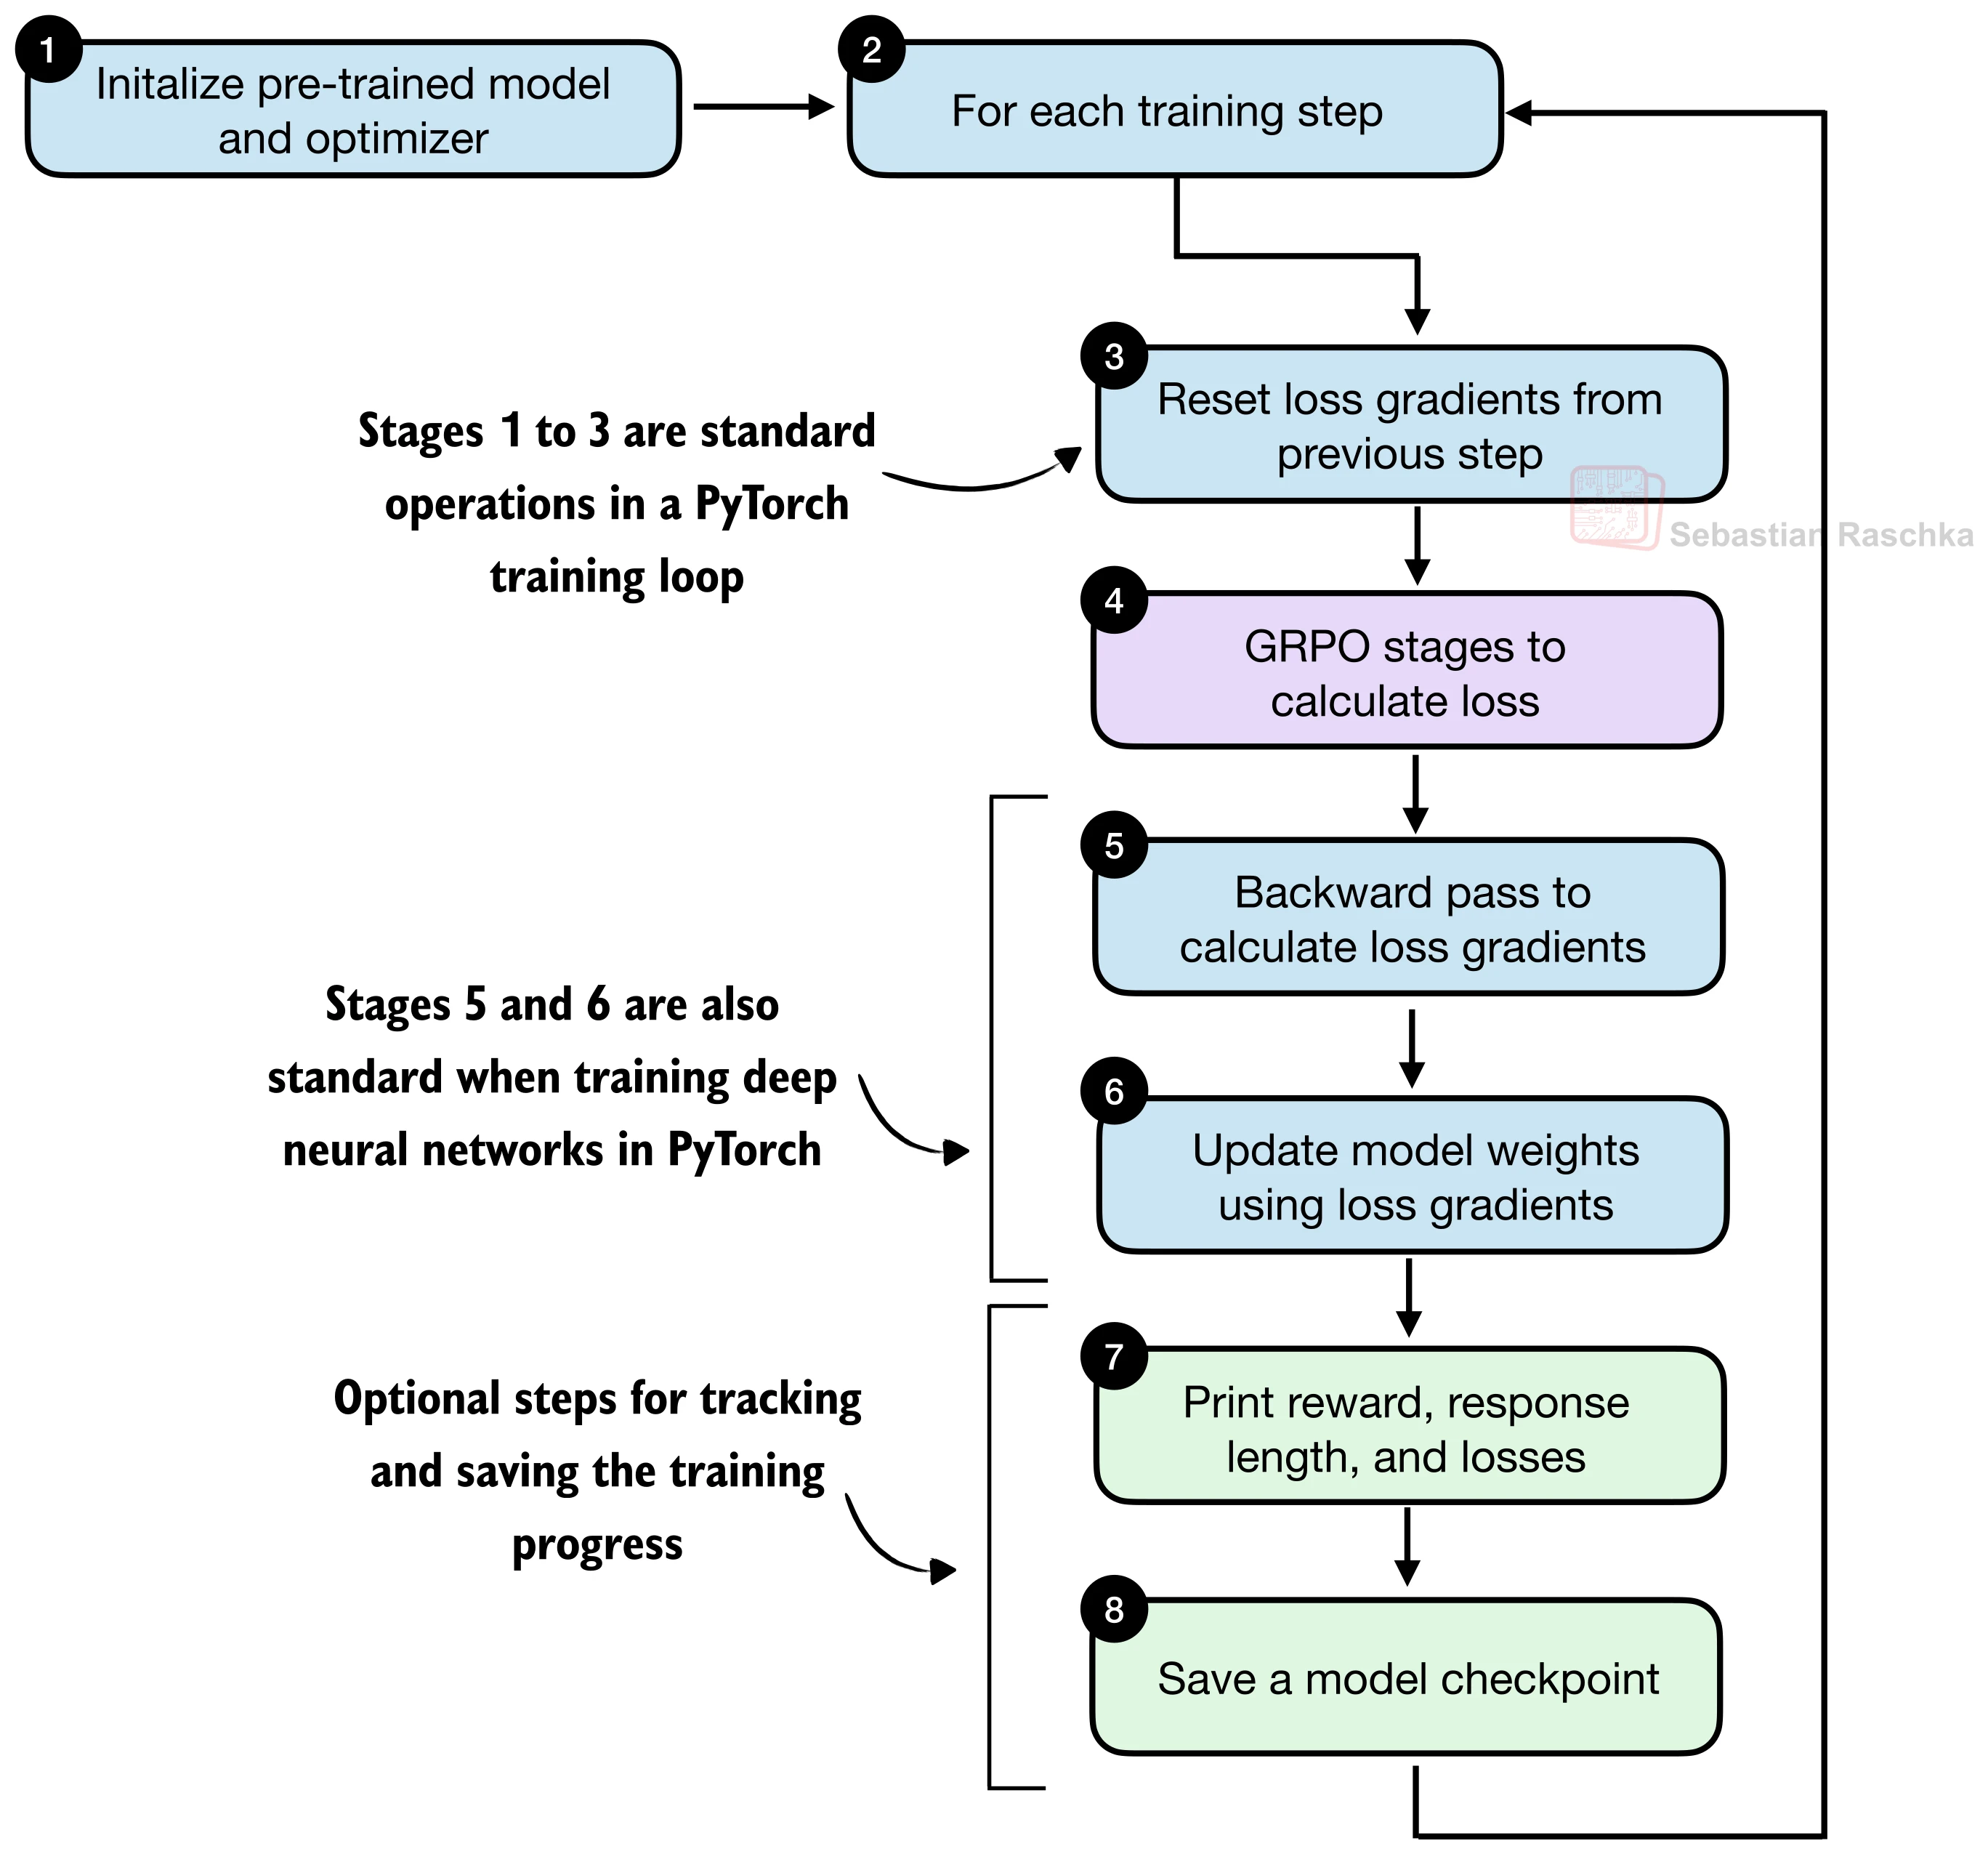

In [50]:
def save_checkpoint(model, checkpoint_dir, step, suffix=""):
    checkpoint_dir = Path(checkpoint_dir)
    checkpoint_dir.mkdir(parents=True, exist_ok=True)
    suffix = f"-{suffix}" if suffix else ""
    ckpt_path = (
        checkpoint_dir /
        f"qwen3-0.6B-rlvr-grpo-step{step:05d}{suffix}.pth"
    )
    torch.save(model.state_dict(), ckpt_path)
    return ckpt_path


def append_csv_metrics(
    csv_log_path,
    step_idx,
    total_steps,
    loss,
    reward_avg,
    avg_response_len,
):
    if not csv_log_path.exists():
        csv_log_path.write_text(
            "step,total_steps,loss,reward_avg,avg_response_len\n",
            encoding="utf-8",
        )
    with csv_log_path.open("a", encoding="utf-8") as f:
        f.write(
            f"{step_idx},{total_steps},{loss:.6f},{reward_avg:.6f},"
            f"{avg_response_len:.6f}\n"
        )

In [51]:
import time

def train_rlvr_grpo(model, tokenizer, data, device, steps = None, lr = 1e-5, num_rollouts=2, max_new_tokens = 256,
                    temperature = 0.8, top_p = 0.9, checkpoint_every=50, checkpoint_dir=".", csv_log_path=None,):
    if steps is None:
        steps = len(data)
    
    #1: initialize optimizer
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr)
    model.train()

    current_step = 0
    if csv_log_path is None:
        timestamp = time.strftime("%Y%m%d_%H%M%S")
        csv_log_path = f"train_rlvr_grpo_metrics_{timestamp}.csv"
    csv_log_path = Path(csv_log_path)

    try:
            #2: iterate over steps
        for step in range(steps):

            #3: reset loss gradient
            optimizer.zero_grad()

            current_step = step + 1
            example = data[step % len(data)]

            #4: compute grpo loss
            stats = compute_grpo_loss(model, tokenizer, example, device, num_rollouts, max_new_tokens, temperature, top_p)
            
            #5: backawrd pass
            stats['loss_tensor'].backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0) #clip for more stability
            
            #6: update weights via optimizer step
            optimizer.step()

            #7: collect rewards/loss/stats
            reward_avg = torch.tensor(stats["rewards"]).mean().item()
            step_tokens = sum(sample["gen_len"] for sample in stats["samples"])
            avg_response_len = (step_tokens / len(stats["samples"]) if stats["samples"] else 0.0)
            append_csv_metrics(csv_log_path, current_step, steps, stats["loss"], reward_avg, avg_response_len)

            # Print step metrics
            print(
                f"[Step {current_step}/{steps}] "
                f"loss={stats['loss']:.4f} "
                f"reward_avg={reward_avg:.3f} "
                f"avg_resp_len={avg_response_len:.1f}"
            )

            # Sample outputs (every 10 steps) 
            if current_step % 10 == 0:
                print(f"[Step {current_step}] sample outputs")
                for i, sample in enumerate(stats["samples"][:3]):
                    text = sample["text"].replace("\n", "\\n")
                    print(
                        f"  {i+1}) reward={sample['reward']:.3f} "
                        f"len={sample['gen_len']}: {text}"
                    )
                print()
            
            # Stage 8: Save model checkpoint
            if checkpoint_every and current_step % checkpoint_every == 0:
                ckpt_path = save_checkpoint(
                    model=model,
                    checkpoint_dir=checkpoint_dir,
                    step=current_step,
                )
                print(f"Saved checkpoint to {ckpt_path}")

    # Save a model checkpoint if we interrupt the training early
    except KeyboardInterrupt:
        ckpt_path = save_checkpoint(
            model=model,
            checkpoint_dir=checkpoint_dir,
            step=max(1, current_step),
            suffix="interrupt",
        )
        print(f"\nKeyboardInterrupt. Saved checkpoint to {ckpt_path}")
        return model

    return model

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"
model.to(device)

torch.manual_seed(0)

train_rlvr_grpo(
    model=model,
    tokenizer=tokenizer,
    data=math_train,
    device=device,
    steps=20,
    num_rollouts=3,
    max_new_tokens=512,
    temperature=0.8,
    top_p=0.9,
    lr=1e-5,
    checkpoint_every=5,
    checkpoint_dir=".",
    csv_log_path="train_rlvr_grpo_metric.csv",
)

[Step 1/20] loss=-0.0000 reward_avg=0.000 avg_resp_len=114.0
